In [46]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
import torchvision.transforms.functional as TF
import torch.nn.functional as F
import random

In [47]:
df =pd.read_csv('../mumax_dataset_ku_by_block_disorder_phy_corrected_3/training_index.csv')
df.head()

,run_id,sample_idx,realization,Dind,Ku1,Aex,alpha,Temp,sigma_nominal,sigma_eff,clamp_fraction,mx3_path,out_dir,returncode,timestamp_start,timestamp_end
0,1,1,0,0.000679,1600000.0,3.100000e-11,1.0,0.0,0.067192,0.063125,0.027344,mumax_dataset_ku_by_block_disorder_phy_correct...,mumax_dataset_ku_by_block_disorder_phy_correct...,0,1.766807e+09,1.766807e+09
1,2,2,0,0.000630,1600000.0,3.100000e-11,1.0,0.0,0.019834,0.020327,0.000000,mumax_dataset_ku_by_block_disorder_phy_correct...,mumax_dataset_ku_by_block_disorder_phy_correct...,0,1.766807e+09,1.766807e+09
2,3,3,0,0.001337,1600000.0,3.100000e-11,1.0,0.0,0.024939,0.025657,0.000000,mumax_dataset_ku_by_block_disorder_phy_correct...,mumax_dataset_ku_by_block_disorder_phy_correct...,0,1.766807e+09,1.766807e+09
3,4,4,0,0.001446,1600000.0,3.100000e-11,1.0,0.0,0.029623,0.030889,0.000000,mumax_dataset_ku_by_block_disorder_phy_correct...,mumax_dataset_ku_by_block_disorder_phy_correct...,0,1.766807e+09,1.766807e+09
4,5,5,0,0.001437,1600000.0,3.100000e-11,1.0,0.0,0.000577,0.000572,0.000000,mumax_dataset_ku_by_block_disorder_phy_correct...,mumax_dataset_ku_by_block_disorder_phy_correct...,0,1.766807e+09,1.766807e+09


In [48]:
# -----------------------------
# 1) Config 
# -----------------------------
CSV_PATH = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_3/training_index.csv")
IMG_DIR = Path("../images/corrected_3")
IMG_INDEX_COL = "run_id"  

COL_D = "Dind"
COL_SIGMA = "sigma_nominal"

IMG_EXT = ".png"   # image extension
IMG_PREFIX = "mz_binary_"   # image name pattern: mz_binary_<idx>.png

BATCH_SIZE = 8
LR = 1e-4
EPOCHS = 100
VAL_RATIO = 0.15
RANDOM_SEED = 42    #42
MODEL_TYPE = "physics_normal"   # Options: "resnet", "physics", "normal", "physics_normal" 
TRAIN_SURROGATE = False   # whether to train surrogate model or load pre-trained weights
USE_AUGMENTATION = False   # True / False para la prueba

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

#-----------------------------------------------------------------

RUN_TAG = "FFT_corr_"   # híbrido: física FFT + correlación
OUT_DIR = Path(f"./outputs_noVariation_16bit_2893imgs/{RUN_TAG}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR = OUT_DIR / "checkpoints"
FIG_DIR  = OUT_DIR / "figures"
MET_DIR  = OUT_DIR / "metrics"

for d in [CKPT_DIR, FIG_DIR, MET_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    
PINN_CKPT_PATH = CKPT_DIR / f"pinn_{RUN_TAG}.pt"
SURR_FFT_PATH  = CKPT_DIR / f"surrogate_fft_{RUN_TAG}.pt"
SURR_CORR_PATH = CKPT_DIR / f"surrogate_corr_{RUN_TAG}.pt"
SURR_PHI_PATH  = CKPT_DIR / f"surrogate_phi_{RUN_TAG}.pt"
SCALER_PATH    = CKPT_DIR / f"scalers_{RUN_TAG}.pkl"

LOSS_PLOT_PATH     = FIG_DIR / f"loss_curves_{RUN_TAG}.png"
HEATMAP_D_PATH     = FIG_DIR / f"heatmap_err_D_{RUN_TAG}.png"
HEATMAP_SIGMA_PATH = FIG_DIR / f"heatmap_err_sigma_{RUN_TAG}.png"

PRED_IMG_DIR = OUT_DIR / "pred_images"
PRED_IMG_DIR.mkdir(parents=True, exist_ok=True)


Device: cuda


In [49]:
def compute_corr_observables(img_batch, n_radial_bins=64):
    """
    Physics-informed REAL-SPACE observables based on spatial correlations C(r).

    Phi_corr =
    [
        C(1), C(2), ..., C(R),
        L_corr
    ]

    Sensitive mainly to disorder (sigma).
    """

    # ---------------------------------------------
    # 1) mz channel in [-1, 1]
    # ---------------------------------------------
    x = img_batch[:, 0, :, :]          # [B, H, W]
    x = 2.0 * x - 1.0

    B, H, W = x.shape
    eps = 1e-8

    # ---------------------------------------------
    # 2) Remove spatial mean (critical)
    # ---------------------------------------------
    x = x - x.mean(dim=(1, 2), keepdim=True)

    # ---------------------------------------------
    # 3) Autocorrelation via Wiener–Khinchin theorem
    # ---------------------------------------------
    Fx = torch.fft.fft2(x)
    P = Fx.real**2 + Fx.imag**2
    C = torch.fft.ifft2(P).real

    # Normalize so that C(0) = 1
    C0 = C[:, 0, 0].clamp_min(eps)
    C = C / C0[:, None, None]

    # ---------------------------------------------
    # 4) Radial distance grid (pixel units)
    # ---------------------------------------------
    yy = torch.fft.fftfreq(H, device=x.device) * H
    xx = torch.fft.fftfreq(W, device=x.device) * W
    Y, X = torch.meshgrid(yy, xx, indexing="ij")
    r = torch.sqrt(X**2 + Y**2)

    r_int = torch.round(r).long()
    max_r = min(n_radial_bins, r_int.max().item())

    # ---------------------------------------------
    # 5) Isotropic radial averaging → C(r)
    # ---------------------------------------------
    C_flat = C.reshape(B, -1)
    r_flat = r_int.reshape(-1)

    Cr = []
    for rr in range(1, max_r + 1):
        mask = (r_flat == rr).float()
        denom = mask.sum().clamp_min(1.0)
        Cr_r = (C_flat * mask).sum(dim=1) / denom
        Cr.append(Cr_r)

    Cr = torch.stack(Cr, dim=1)  # [B, R]

    # Pad to fixed length if needed
    if Cr.shape[1] < n_radial_bins:
        pad = torch.zeros(B, n_radial_bins - Cr.shape[1], device=x.device)
        Cr = torch.cat([Cr, pad], dim=1)

    # ---------------------------------------------
    # 6) Correlation length L_corr
    #    (first zero crossing)
    # ---------------------------------------------
    sign = torch.sign(Cr)
    zero_cross = (sign[:, :-1] * sign[:, 1:] < 0)

    L_corr = torch.where(
        zero_cross.any(dim=1),
        zero_cross.float().argmax(dim=1) + 1,
        torch.full((B,), float(n_radial_bins), device=x.device)
    )

    # ---------------------------------------------
    # 7) Final Phi_corr
    # ---------------------------------------------
    Phi_corr = torch.cat(
        [
            Cr,
            L_corr.unsqueeze(1)
        ],
        dim=1
    )

    return Phi_corr


def compute_fft_observables(img_batch, n_radial_bins=64):
    """
    Physics-informed FOURIER-SPACE observables based on isotropic power spectrum.

    Phi_fft =
    [
        S_norm(k_1)...S_norm(k_n),
        <k>, Var(k), Skew(k), Kurt(k),
        peak_ratio, high_k_energy
    ]

    Sensitive mainly to periodicity and DMI strength (D).
    """

    # ---------------------------------------------
    # 1) mz channel in [-1, 1]
    # ---------------------------------------------
    x = img_batch[:, 0, :, :]          # [B, H, W]
    x = 2.0 * x - 1.0

    B, H, W = x.shape
    eps = 1e-8

    # ---------------------------------------------
    # 2) Remove DC component
    # ---------------------------------------------
    x = x - x.mean(dim=(1, 2), keepdim=True)

    # ---------------------------------------------
    # 3) Fourier transform and power spectrum
    # ---------------------------------------------
    F = torch.fft.fft2(x)
    F = torch.fft.fftshift(F, dim=(1, 2))
    P = torch.log1p(torch.abs(F) ** 2)

    # ---------------------------------------------
    # 4) Radial wavevector grid (dimensionless)
    # ---------------------------------------------
    yy, xx = torch.meshgrid(
        torch.linspace(-1, 1, H, device=x.device),
        torch.linspace(-1, 1, W, device=x.device),
        indexing="ij"
    )
    k = torch.sqrt(xx**2 + yy**2)

    k_flat = k.reshape(-1)
    P_flat = P.reshape(B, -1)

    k_max = k_flat.max()
    bin_edges = torch.linspace(0.0, k_max, n_radial_bins + 1, device=x.device)
    k_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # ---------------------------------------------
    # 5) Isotropic radial averaging → S(k)
    # ---------------------------------------------
    S_bins = []
    for i in range(n_radial_bins):
        mask = (k_flat >= bin_edges[i]) & (k_flat < bin_edges[i + 1])
        mask = mask.unsqueeze(0)

        denom = mask.sum(dim=1).clamp_min(1.0)
        S_i = (P_flat * mask).sum(dim=1) / denom
        S_bins.append(S_i)

    S_bins = torch.stack(S_bins, dim=1)  # [B, n_bins]

    # Normalize spectrum (critical for stability)
    S_norm = S_bins / (S_bins.sum(dim=1, keepdim=True) + eps)

    # ---------------------------------------------
    # 6) Spectral moments
    # ---------------------------------------------
    k_c = k_centers.unsqueeze(0)

    mu1 = (S_norm * k_c).sum(dim=1)
    mu2 = (S_norm * (k_c - mu1.unsqueeze(1))**2).sum(dim=1)

    mu3 = (
        (S_norm * (k_c - mu1.unsqueeze(1))**3).sum(dim=1)
        / (mu2.sqrt()**3 + eps)
    )

    mu4 = (
        (S_norm * (k_c - mu1.unsqueeze(1))**4).sum(dim=1)
        / (mu2**2 + eps)
    )

    # ---------------------------------------------
    # 7) Order / disorder diagnostics
    # ---------------------------------------------
    peak_val, _ = S_bins.max(dim=1)
    background = S_bins.mean(dim=1)
    peak_ratio = peak_val / (background + eps)

    high_k_mask = k_c > 0.6 * k_max
    high_k_energy = (S_norm * high_k_mask).sum(dim=1)

    # ---------------------------------------------
    # 8) Final Phi_fft
    # ---------------------------------------------
    Phi_fft = torch.cat(
        [
            S_norm,
            mu1.unsqueeze(1),
            mu2.unsqueeze(1),
            mu3.unsqueeze(1),
            mu4.unsqueeze(1),
            peak_ratio.unsqueeze(1),
            high_k_energy.unsqueeze(1)
        ],
        dim=1
    )

    return Phi_fft



In [50]:
# ==============================================================================
# CORRECTED MzDataset with 16-bit loading and parameter filtering
# ==============================================================================

# Add this helper function at the top of your notebook/script
def load_16bit_image(path):
    """
    Load 16-bit grayscale PNG preserving full dynamic range.
    
    Returns:
        np.ndarray of shape (H, W) with values in [0, 1] as float32
    """
    img = Image.open(path)
    
    if img.mode == 'I;16':
        # Proper 16-bit grayscale
        arr = np.array(img, dtype=np.uint16)
        arr = arr.astype(np.float32) / 65535.0
    elif img.mode == 'I':
        # 32-bit integer (sometimes PIL does this)
        arr = np.array(img, dtype=np.float32)
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    elif img.mode == 'L':
        # Already 8-bit (fallback with warning)
        print(f"WARNING: {path} loaded as 8-bit!")
        arr = np.array(img, dtype=np.float32) / 255.0
    else:
        raise ValueError(f"Unexpected image mode: {img.mode}")
    
    return arr


class MzDataset(Dataset):
    """
    Dataset for mz images and (D, sigma) targets.
    
    FIXES APPLIED:
    1. Proper 16-bit image loading (preserves domain wall information)
    2. Optional filtering of problematic parameter ranges
    
    IMPORTANT:
    - This dataset is AGNOSTIC to the physics used (FFT, C(r), or hybrid).
    - Physical observables Phi are computed OUTSIDE the dataset,
      inside the training loop, to keep full flexibility.
    """

    def __init__(self, csv_path, img_dir, index_col,
                 transform=None,
                 target_mean=None,
                 target_std=None,
                 # NEW: Filtering options
                 filter_low_D=True,
                 D_min_threshold=0.3e-3,      # 0.3 mJ/m² in SI units
                 filter_low_sigma=True,
                 sigma_min_threshold=0.02):

        self.df = pd.read_csv(csv_path)
        self.df.set_index(index_col, inplace=True)

        self.img_dir = Path(img_dir)
        self.transform = transform

        self.records = []
        
        # Counters for filtered samples
        n_filtered_D = 0
        n_filtered_sigma = 0

        # -------------------------------------------------
        # Find all available images
        # -------------------------------------------------
        img_files = sorted(self.img_dir.glob(f"{IMG_PREFIX}*{IMG_EXT}"))

        if len(img_files) == 0:
            raise RuntimeError(f"No images found in {img_dir}")

        for img_path in img_files:
            # Extract run_id from filename
            try:
                run_id = int(img_path.stem.replace(IMG_PREFIX, ""))
            except ValueError:
                continue  # skip malformed filenames

            # Only keep images with matching CSV entry
            if run_id not in self.df.index:
                continue

            row = self.df.loc[run_id]
            D = float(row[COL_D])
            sigma = float(row[COL_SIGMA])
            
            # -------------------------------------------------
            # NEW: Filter problematic parameter ranges
            # -------------------------------------------------
            if filter_low_D and D < D_min_threshold:
                n_filtered_D += 1
                continue
                
            if filter_low_sigma and sigma < sigma_min_threshold:
                n_filtered_sigma += 1
                continue

            self.records.append({
                "img_path": img_path,
                "D": D,
                "sigma": sigma,
                "run_id": run_id
            })

        if len(self.records) == 0:
            raise RuntimeError("No valid (image, label) pairs found.")

        self.target_mean = target_mean
        self.target_std  = target_std

        print(f"[MzDataset] Loaded {len(self.records)} samples from {img_dir}")
        if filter_low_D:
            print(f"  Filtered {n_filtered_D} samples with D < {D_min_threshold*1e3:.1f} mJ/m²")
        if filter_low_sigma:
            print(f"  Filtered {n_filtered_sigma} samples with σ < {sigma_min_threshold}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        # -------------------------------------------------
        # FIXED: Load image with proper 16-bit handling
        # -------------------------------------------------
        arr = load_16bit_image(r["img_path"])
        
        # Convert to tensor [1, H, W]
        img = torch.from_numpy(arr).unsqueeze(0).float()

        # Apply transforms if any (note: transforms now receive a tensor)
        if self.transform is not None:
            img = self.transform(img)

        # Ensure float32 tensor (important for FFT stability)
        img = img.float()

        # Expand to 3 channels (CNN compatibility)
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        # -------------------------------------------------
        # Targets: (D, sigma)
        # -------------------------------------------------
        target = np.array([r["D"], r["sigma"]], dtype=np.float32)

        if self.target_mean is not None:
            target = (target - self.target_mean) / self.target_std

        target = torch.tensor(target, dtype=torch.float32)

        return img, target


# ==============================================================================
# IMPORTANT: Update your transforms!
# ==============================================================================
# Since we're now loading as numpy array -> tensor directly,
# we need to adjust the transforms.
# 
# OLD (doesn't work anymore):
#   train_tf = T.Compose([
#       T.RandomHorizontalFlip(),
#       T.ToTensor(),
#   ])
#
# NEW (works with tensor input):
#   train_tf = T.Compose([
#       T.RandomHorizontalFlip(),
#       T.RandomVerticalFlip(),
#   ])
#   # Note: No ToTensor() needed since we already have a tensor
#
# Or simply use None for transforms if not using augmentation:
#   train_tf = None

In [95]:
# ---------------------------------------------------------
# 1. Define transforms
# ---------------------------------------------------------

class RandomRot90:
    """Random 90-degree rotation for tensor input."""
    def __call__(self, x):
        k = random.randint(0, 3)
        # x is already a tensor [C, H, W]
        return TF.rotate(x, k * 90)


# ---------------------------------------------------------
# IMPORTANT PHYSICAL NOTE:
# For PINN models with FFT / C(r) constraints,
# geometric augmentations (rotations, flips) are NOT strictly invariant
# due to discretization and radial binning.
#
# Therefore:
# - Augmentation is DISABLED automatically for physics-based models.
# ---------------------------------------------------------

USE_PHYSICS = MODEL_TYPE in ["physics", "physics_normal"]

# ---------------------------------------------------------
# FIXED: Removed T.ToTensor() since we now load as tensor directly
# ---------------------------------------------------------
if USE_AUGMENTATION and not USE_PHYSICS:
    train_tf = T.Compose([
        T.RandomHorizontalFlip(),
        T.RandomVerticalFlip(),
        RandomRot90(),
        # NO T.ToTensor() - data is already a tensor from load_16bit_image
    ])
else:
    # No transforms needed - data is already a tensor
    train_tf = None

# No transforms needed for validation
val_tf = None


# ---------------------------------------------------------
# 2. Base dataset with filtering enabled
# ---------------------------------------------------------
base_dataset = MzDataset(
    CSV_PATH,
    IMG_DIR,
    IMG_INDEX_COL,
    transform=None,
    # NEW: Enable filtering of problematic parameter ranges
    filter_low_D=True,
    D_min_threshold=0.3e-3,      # Filter D < 0.3 mJ/m²
    filter_low_sigma=True,
    sigma_min_threshold=0.02     # Filter σ < 0.02
)


# ---------------------------------------------------------
# 3. Train / Val split (reproducible)
# ---------------------------------------------------------
val_size = int(len(base_dataset) * VAL_RATIO)
train_size = len(base_dataset) - val_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(
    base_dataset,
    [train_size, val_size],
    generator=generator
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")


# ---------------------------------------------------------
# 4. Inject transforms and target normalization
#    (CRITICAL STEP — correct implementation)
# ---------------------------------------------------------

train_targets = np.array(
    [[base_dataset.records[i]["D"], base_dataset.records[i]["sigma"]]
     for i in train_dataset.indices],
    dtype=np.float32
)

t_mean = train_targets.mean(axis=0)
t_std  = train_targets.std(axis=0)
t_std[t_std == 0] = 1.0   # numerical safety

print(f"Target normalization:")
print(f"  D:     mean={t_mean[0]*1e3:.3f} mJ/m², std={t_std[0]*1e3:.3f}")
print(f"  sigma: mean={t_mean[1]:.4f}, std={t_std[1]:.4f}")

# Inject into underlying dataset
train_dataset.dataset.transform = train_tf
train_dataset.dataset.target_mean = t_mean
train_dataset.dataset.target_std  = t_std

val_dataset.dataset.transform = val_tf
val_dataset.dataset.target_mean = t_mean
val_dataset.dataset.target_std  = t_std


# ---------------------------------------------------------
# 5. DataLoaders
# ---------------------------------------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True   # important for stable physics batches
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
print(f"DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

[MzDataset] Loaded 2172 samples from ../images/corrected_3
  Filtered 483 samples with D < 0.3 mJ/m²
  Filtered 235 samples with σ < 0.02
Train size: 1847, Val size: 325
Target normalization:
  D:     mean=0.901 mJ/m², std=0.349
  sigma: mean=0.0841, std=0.0382
DataLoaders ready. Train batches: 230, Val batches: 41


In [96]:
# -----------------------------
# Physics-Normal CNN (IMPROVED)
# imagen → (D, sigma)
# -----------------------------
class PhysicsNormalCNN(nn.Module):
    """
    Baseline-consistent CNN + gradient + structure tensor coherence.
    """

    def __init__(self):
        super().__init__()

        in_channels = 5  # 3 mz + |∇m| + coherence

        # Sobel filters (IDENTICAL to baseline)
        self.register_buffer(
            "sobel_x",
            torch.tensor([
                [[-1, 0, 1],
                 [-2, 0, 2],
                 [-1, 0, 1]]
            ], dtype=torch.float32).unsqueeze(0)
        )
        self.register_buffer(
            "sobel_y",
            torch.tensor([
                [[-1, -2, -1],
                 [ 0,  0,  0],
                 [ 1,  2,  1]]
            ], dtype=torch.float32).unsqueeze(0)
        )

        # Local averaging kernel for structure tensor
        self.register_buffer(
            "avg_kernel",
            torch.ones(1, 1, 3, 3, dtype=torch.float32) / 9.0
        )

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            conv_block(in_channels, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 512),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        # x: [B, 3, H, W]
        gray = x[:, 0:1, :, :]

        # =====================================================
        # FORCE FLOAT32 FOR PHYSICS FEATURES (CRITICAL FIX)
        # =====================================================
        with torch.amp.autocast('cuda',enabled=False):
            gray = gray.float()

            # -----------------------------
            # 1) Gradients (BASELINE EXACT)
            # -----------------------------
            Ix = F.conv2d(gray, self.sobel_x, padding=1)
            Iy = F.conv2d(gray, self.sobel_y, padding=1)

            grad_mag = torch.sqrt(Ix**2 + Iy**2 + 1e-8)

            # EXACT baseline behavior: global max
            grad_mag = grad_mag / (grad_mag.max() + 1e-8)

            # -----------------------------------------
            # 2) STRUCTURE TENSOR (NEW, FLOAT32 SAFE)
            # -----------------------------------------
            Jxx = F.conv2d(Ix**2, self.avg_kernel, padding=1)
            Jyy = F.conv2d(Iy**2, self.avg_kernel, padding=1)
            Jxy = F.conv2d(Ix * Iy, self.avg_kernel, padding=1)

            trace = Jxx + Jyy

            lambda_diff = torch.sqrt(
                torch.clamp((Jxx - Jyy)**2 + 4 * Jxy**2, min=0.0)
            )

            # IMPORTANT: eps must be fp32-real
            coherence = lambda_diff / (trace + 1e-6)

            # EXACT baseline behavior: global max
            coherence = coherence / (coherence.max() + 1e-8)

        # Cast back to match CNN dtype (fp16 if AMP is on)
        grad_mag = grad_mag.to(x.dtype)
        coherence = coherence.to(x.dtype)

        # -----------------------------
        # 3) Concatenate channels
        # -----------------------------
        x = torch.cat([x, grad_mag, coherence], dim=1)

        x = self.features(x)
        x = self.pool(x)
        return self.regressor(x)






# ------------------------------------------------
# Surrogate physics model: (D, sigma) → Phi
# ------------------------------------------------
class SurrogatePhysics(nn.Module):
    """
    Maps physical parameters (D, sigma) to expected observables Phi.
    
    This learns the forward physics model:
        g(D, σ) → Φ
    
    Where Φ can be FFT-based or correlation-based observables.
    """
    
    def __init__(self, phi_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),  # Added layer for more capacity
            nn.ReLU(),
            nn.Linear(256, phi_dim)
        )

    def forward(self, params):
        """
        params: tensor [B, 2] with (D, sigma) in PHYSICAL units
        """
        return self.net(params)

In [97]:
# ==============================================================================
# CORRECTED Surrogate Dataset and Helper Functions
# ==============================================================================
# KEY FIX: Proper 16-bit image loading in all functions
# ==============================================================================


# -------------------------------------------------
# Surrogate dataset: groups images by (D, sigma)
# -------------------------------------------------
class SurrogateDataset(torch.utils.data.Dataset):
    """
    Dataset of unique (D, sigma) pairs.
    Each item contains ALL images generated with those parameters.
    
    NOTE: This uses the base_dataset which already has filtering applied,
    so only valid parameter combinations are included.
    """

    def __init__(self, base_dataset):
        groups = {}

        for r in base_dataset.records:
            key = (r["D"], r["sigma"])
            groups.setdefault(key, []).append(r["img_path"])

        self.param_keys = list(groups.keys())
        self.groups = groups
        
        print(f"[SurrogateDataset] Created {len(self.param_keys)} unique (D, sigma) groups")

    def __len__(self):
        return len(self.param_keys)

    def __getitem__(self, idx):
        D, sigma = self.param_keys[idx]
        img_paths = self.groups[(D, sigma)]

        return {
            "params": torch.tensor([D, sigma], dtype=torch.float32),
            "img_paths": img_paths
        }


# -------------------------------------------------
# FIXED: Helper to load images with 16-bit support
# -------------------------------------------------
def load_16bit_image(path):
    """
    Load 16-bit grayscale PNG preserving full dynamic range.
    
    Returns:
        np.ndarray of shape (H, W) with values in [0, 1] as float32
    """
    img = Image.open(path)
    
    if img.mode == 'I;16':
        # Proper 16-bit grayscale
        arr = np.array(img, dtype=np.uint16)
        arr = arr.astype(np.float32) / 65535.0
    elif img.mode == 'I':
        # 32-bit integer (sometimes PIL does this)
        arr = np.array(img, dtype=np.float32)
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    elif img.mode == 'L':
        # Already 8-bit (fallback with warning)
        print(f"WARNING: {path} loaded as 8-bit!")
        arr = np.array(img, dtype=np.float32) / 255.0
    else:
        raise ValueError(f"Unexpected image mode: {img.mode}")
    
    return arr


# -------------------------------------------------
# FIXED: Load group of images with 16-bit support
# -------------------------------------------------
def load_group_imgs(img_paths, device):
    """
    Load ALL images for one (D, sigma) group.
    
    FIXED: Uses proper 16-bit loading instead of .convert("L")
    
    Returns:
        Tensor of shape [N, 3, H, W] on device
    """
    imgs = []
    for p in img_paths:
        # FIXED: Use 16-bit loader
        arr = load_16bit_image(p)
        
        # Convert to tensor [1, H, W]
        img = torch.from_numpy(arr).unsqueeze(0).float()
        
        # Expand to 3 channels [3, H, W]
        img = img.repeat(3, 1, 1)
        
        imgs.append(img)
    
    return torch.stack(imgs).to(device)  # [N, 3, H, W]


# -------------------------------------------------
# FIXED: Compute average Phi_fft for one (D, sigma)
# -------------------------------------------------
def compute_phi_bar_fft(img_paths, device, n_radial_bins=64):
    """
    Compute average FFT observables for a group of images.
    
    FIXED: Uses proper 16-bit loading
    """
    Phi_list = []

    for p in img_paths:
        # FIXED: Use 16-bit loader instead of Image.open().convert("L")
        arr = load_16bit_image(p)
        
        # Convert to tensor [1, 1, H, W] for batch processing
        img = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).float().to(device)
        
        # Expand to 3 channels [1, 3, H, W]
        img = img.repeat(1, 3, 1, 1)

        with torch.no_grad():
            Phi = compute_fft_observables(img, n_radial_bins)

        Phi_list.append(Phi.squeeze(0))

    Phi_bar = torch.stack(Phi_list, dim=0).mean(dim=0)
    return Phi_bar


# -------------------------------------------------
# FIXED: Compute average Phi_corr for one (D, sigma)
# -------------------------------------------------
def compute_phi_bar_corr(img_paths, device, n_radial_bins=64):
    """
    Compute average correlation observables for a group of images.
    
    FIXED: Uses proper 16-bit loading
    """
    Phi_list = []

    for p in img_paths:
        # FIXED: Use 16-bit loader instead of Image.open().convert("L")
        arr = load_16bit_image(p)
        
        # Convert to tensor [1, 1, H, W] for batch processing
        img = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).float().to(device)
        
        # Expand to 3 channels [1, 3, H, W]
        img = img.repeat(1, 3, 1, 1)

        with torch.no_grad():
            Phi = compute_corr_observables(img, n_radial_bins)

        Phi_list.append(Phi.squeeze(0))

    Phi_bar = torch.stack(Phi_list, dim=0).mean(dim=0)
    return Phi_bar


# -------------------------------------------------
# Compute global Phi_fft mean / std (unchanged logic, uses fixed functions)
# -------------------------------------------------
def compute_phi_fft_stats(surr_dataset, device, n_radial_bins=64):
    """
    Compute mean and std of Phi_fft across all (D, sigma) groups.
    Used for normalizing the surrogate training targets.
    """
    Phi_all = []

    print("Computing Phi_fft statistics...")
    for i, item in enumerate(surr_dataset):
        Phi_bar = compute_phi_bar_fft(
            item["img_paths"], device, n_radial_bins
        )
        Phi_all.append(Phi_bar.cpu())
        
        if (i + 1) % 100 == 0:
            print(f"  Processed {i+1}/{len(surr_dataset)} groups")

    Phi_all = torch.stack(Phi_all)

    Phi_mean = Phi_all.mean(dim=0)
    Phi_std  = Phi_all.std(dim=0)
    Phi_std[Phi_std < 1e-8] = 1e-8  # Avoid division by zero

    print(f"  Phi_fft stats: mean range [{Phi_mean.min():.4f}, {Phi_mean.max():.4f}]")
    print(f"  Phi_fft stats: std range [{Phi_std.min():.4f}, {Phi_std.max():.4f}]")

    return Phi_mean.to(device), Phi_std.to(device)


# -------------------------------------------------
# Compute global Phi_corr mean / std (unchanged logic, uses fixed functions)
# -------------------------------------------------
def compute_phi_corr_stats(surr_dataset, device, n_radial_bins=64):
    """
    Compute mean and std of Phi_corr across all (D, sigma) groups.
    Used for normalizing the surrogate training targets.
    """
    Phi_all = []

    print("Computing Phi_corr statistics...")
    for i, item in enumerate(surr_dataset):
        Phi_bar = compute_phi_bar_corr(
            item["img_paths"], device, n_radial_bins
        )
        Phi_all.append(Phi_bar.cpu())
        
        if (i + 1) % 100 == 0:
            print(f"  Processed {i+1}/{len(surr_dataset)} groups")

    Phi_all = torch.stack(Phi_all)

    Phi_mean = Phi_all.mean(dim=0)
    Phi_std  = Phi_all.std(dim=0)
    Phi_std[Phi_std < 1e-8] = 1e-8  # Avoid division by zero

    print(f"  Phi_corr stats: mean range [{Phi_mean.min():.4f}, {Phi_mean.max():.4f}]")
    print(f"  Phi_corr stats: std range [{Phi_std.min():.4f}, {Phi_std.max():.4f}]")

    return Phi_mean.to(device), Phi_std.to(device)


# -------------------------------------------------
# Instantiate surrogate dataset and split
# -------------------------------------------------
# NOTE: base_dataset must be created FIRST with filtering enabled!
# This ensures surr_dataset only contains valid (D, sigma) pairs.

surr_dataset = SurrogateDataset(base_dataset)

generator = torch.Generator().manual_seed(RANDOM_SEED)

val_size = int(len(surr_dataset) * VAL_RATIO)
train_size = len(surr_dataset) - val_size

train_surr, val_surr = random_split(
    surr_dataset,
    [train_size, val_size],
    generator=generator
)

print(
    f"Surrogate dataset - Train size: {len(train_surr)}, "
    f"Val size: {len(val_surr)}"
)

[SurrogateDataset] Created 2172 unique (D, sigma) groups
Surrogate dataset - Train size: 1847, Val size: 325


In [98]:
# ==============================================================================
# CORRECTED Surrogate Training Code
# ==============================================================================
# KEY FIX: Proper 16-bit image loading in load_group_imgs
# ==============================================================================

if TRAIN_SURROGATE:

    print("\n==============================")
    print(f" TRAINING SURROGATE MODELS ({RUN_TAG})")
    print("   g_fft(D, sigma)  →  <Phi_fft>")
    print("   g_corr(D, sigma) →  <Phi_corr>")
    print("==============================\n")

    # -------------------------------------------------
    # FIXED: Helper to load 16-bit images
    # -------------------------------------------------
    def load_16bit_image(path):
        """
        Load 16-bit grayscale PNG preserving full dynamic range.
        Returns np.ndarray of shape (H, W) with values in [0, 1]
        """
        img = Image.open(path)
        
        if img.mode == 'I;16':
            arr = np.array(img, dtype=np.uint16)
            arr = arr.astype(np.float32) / 65535.0
        elif img.mode == 'I':
            arr = np.array(img, dtype=np.float32)
            arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        elif img.mode == 'L':
            print(f"WARNING: {path} loaded as 8-bit!")
            arr = np.array(img, dtype=np.float32) / 255.0
        else:
            raise ValueError(f"Unexpected image mode: {img.mode}")
        
        return arr

    # -------------------------------------------------
    # FIXED: Load ALL images for one (D, sigma) group
    # Now uses proper 16-bit loading
    # -------------------------------------------------
    def load_group_imgs(img_paths, device):
        """
        Load all images for a (D, sigma) group with 16-bit support.
        
        Returns:
            Tensor [N, 3, H, W] on device
        """
        imgs = []
        for p in img_paths:
            # FIXED: Use 16-bit loader instead of .convert("L")
            arr = load_16bit_image(p)
            
            # Convert to tensor [1, H, W]
            img = torch.from_numpy(arr).unsqueeze(0).float()
            
            # Expand to 3 channels [3, H, W]
            img = img.repeat(3, 1, 1)
            
            imgs.append(img)
        
        return torch.stack(imgs).to(device)  # [N, 3, H, W]


    # -------------------------------------------------
    # Helper: compute Phi_bar for a group (FFT or CORR)
    # (unchanged - operates on already-loaded tensors)
    # -------------------------------------------------
    def compute_group_phi_bar(imgs, physics, n_radial_bins=64):
        """
        imgs: [N, 3, H, W] tensor on device
        returns: Phi_bar [phi_dim]
        """
        with torch.no_grad():
            if physics == "fft":
                Phi = compute_fft_observables(imgs, n_radial_bins=n_radial_bins)
            elif physics == "corr":
                Phi = compute_corr_observables(imgs, n_radial_bins=n_radial_bins)
            else:
                raise ValueError("physics must be 'fft' or 'corr'")
            Phi_bar = Phi.mean(dim=0)
        return Phi_bar


    # -------------------------------------------------
    # Helper: compute Phi_mean/std from TRAIN surrogate set
    # -------------------------------------------------
    def compute_phi_stats_from_trainset(train_surr, physics, device, n_radial_bins=64):
        """
        Compute normalization statistics from training set.
        """
        Phi_list = []
        
        print(f"  Computing {physics.upper()} statistics from {len(train_surr)} groups...")
        
        with torch.no_grad():
            for i, item in enumerate(train_surr):
                imgs = load_group_imgs(item["img_paths"], device)
                Phi_bar = compute_group_phi_bar(imgs, physics, n_radial_bins=n_radial_bins)
                Phi_list.append(Phi_bar.cpu())
                
                if (i + 1) % 100 == 0:
                    print(f"    Processed {i+1}/{len(train_surr)} groups")

        Phi_all = torch.stack(Phi_list, dim=0)
        Phi_mean = Phi_all.mean(dim=0)
        Phi_std  = Phi_all.std(dim=0)
        Phi_std[Phi_std < 1e-8] = 1e-8  # Numerical safety

        return Phi_mean.to(device), Phi_std.to(device)


    # -------------------------------------------------
    # Helper: train one surrogate (generic)
    # -------------------------------------------------
    def train_one_surrogate(physics, ckpt_path, curve_path, n_radial_bins=64, epochs=120, lr=1e-3):

        print("\n----------------------------------------")
        print(f" Training surrogate: {physics.upper()}")
        print("----------------------------------------")

        # Determine phi_dim dynamically
        sample_item = train_surr[0]
        sample_imgs = load_group_imgs(sample_item["img_paths"], device)
        with torch.no_grad():
            sample_phi_bar = compute_group_phi_bar(sample_imgs, physics, n_radial_bins=n_radial_bins)
        phi_dim = sample_phi_bar.shape[0]
        print(f"  Phi dimension: {phi_dim}")

        # Build model (using improved architecture with extra layer)
        surrogate = SurrogatePhysics(phi_dim=phi_dim).to(device)
        optimizer_surr = torch.optim.Adam(surrogate.parameters(), lr=lr)
        
        # Use learning rate scheduler for better convergence
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_surr, mode='min', factor=0.5, patience=15
        )
        
        criterion = nn.MSELoss()

        # Compute normalization from TRAIN surrogate set
        Phi_mean, Phi_std = compute_phi_stats_from_trainset(
            train_surr, physics, device, n_radial_bins=n_radial_bins
        )

        print(f"  Phi mean (first 5): {Phi_mean[:5].detach().cpu().numpy()}")
        print(f"  Phi std  (first 5): {Phi_std[:5].detach().cpu().numpy()}")

        train_losses = []
        val_losses = []
        best_val_loss = float('inf')
        best_state = None

        for epoch in range(1, epochs + 1):

            # -----------------------------
            # TRAIN
            # -----------------------------
            surrogate.train()
            running_train = 0.0

            for item in train_surr:
                params = item["params"].to(device)
                imgs = load_group_imgs(item["img_paths"], device)

                # Target Phi_bar (normalized)
                Phi_bar = compute_group_phi_bar(imgs, physics, n_radial_bins=n_radial_bins)
                Phi_bar_norm = (Phi_bar - Phi_mean) / Phi_std

                Phi_pred = surrogate(params.unsqueeze(0)).squeeze(0)

                loss = criterion(Phi_pred, Phi_bar_norm)

                optimizer_surr.zero_grad()
                loss.backward()
                optimizer_surr.step()

                running_train += loss.item()

            train_loss = running_train / len(train_surr)
            train_losses.append(train_loss)

            # -----------------------------
            # VALIDATION
            # -----------------------------
            surrogate.eval()
            running_val = 0.0

            with torch.no_grad():
                for item in val_surr:
                    params = item["params"].to(device)
                    imgs = load_group_imgs(item["img_paths"], device)

                    Phi_bar = compute_group_phi_bar(imgs, physics, n_radial_bins=n_radial_bins)
                    Phi_bar_norm = (Phi_bar - Phi_mean) / Phi_std

                    Phi_pred = surrogate(params.unsqueeze(0)).squeeze(0)

                    running_val += criterion(Phi_pred, Phi_bar_norm).item()

            val_loss = running_val / len(val_surr)
            val_losses.append(val_loss)
            
            # Update scheduler
            scheduler.step(val_loss)
            
            # Save best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = surrogate.state_dict().copy()

            if epoch % 10 == 0 or epoch == 1:
                lr_now = optimizer_surr.param_groups[0]['lr']
                print(
                    f"  [{physics.upper()}] Epoch {epoch:03d}/{epochs} | "
                    f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {lr_now:.1e}"
                )

        # Restore best model
        if best_state is not None:
            surrogate.load_state_dict(best_state)
            print(f"  Restored best model (val_loss={best_val_loss:.6f})")

        # Freeze and save
        for p in surrogate.parameters():
            p.requires_grad = False
        surrogate.eval()

        torch.save({
            "state_dict": surrogate.state_dict(),
            "Phi_mean": Phi_mean.detach().cpu(),
            "Phi_std": Phi_std.detach().cpu(),
            "phi_dim": phi_dim,
            "physics": physics,
            "n_radial_bins": n_radial_bins,
            "run_tag": RUN_TAG,
            "best_val_loss": best_val_loss
        }, ckpt_path)

        print(f"\n  Surrogate saved to '{ckpt_path}'")

        # Plot curve
        plt.figure(figsize=(8, 5))
        plt.plot(train_losses, label="Train Loss", linewidth=2)
        plt.plot(val_losses, label="Validation Loss", linewidth=2)
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title(f"Surrogate Training ({physics.upper()} | {RUN_TAG})")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(curve_path, dpi=300)
        plt.show()

        return surrogate, (Phi_mean, Phi_std)


    # -------------------------------------------------
    # Train BOTH surrogates
    # -------------------------------------------------
    surrogate_fft, (Phi_fft_mean, Phi_fft_std) = train_one_surrogate(
        physics="fft",
        ckpt_path=SURR_FFT_PATH,
        curve_path=FIG_DIR / f"surrogate_train_val_curve_fft_{RUN_TAG}.png",
        n_radial_bins=64,
        epochs=150,  # Increased epochs
        lr=1e-3
    )

    surrogate_corr, (Phi_corr_mean, Phi_corr_std) = train_one_surrogate(
        physics="corr",
        ckpt_path=SURR_CORR_PATH,
        curve_path=FIG_DIR / f"surrogate_train_val_curve_corr_{RUN_TAG}.png",
        n_radial_bins=64,
        epochs=150,  # Increased epochs
        lr=1e-3
    )
    
    # -------------------------------------------------
    # VERIFY SURROGATE QUALITY (NEW!)
    # -------------------------------------------------
    print("\n==============================")
    print(" SURROGATE QUALITY VERIFICATION")
    print("==============================\n")
    
    def verify_surrogate(surrogate, val_surr, physics, Phi_mean, Phi_std, device):
        """Compute R² score for surrogate on validation set."""
        all_true = []
        all_pred = []
        
        surrogate.eval()
        with torch.no_grad():
            for item in val_surr:
                params = item["params"].to(device)
                imgs = load_group_imgs(item["img_paths"], device)
                
                Phi_bar = compute_group_phi_bar(imgs, physics, n_radial_bins=64)
                Phi_bar_norm = (Phi_bar - Phi_mean) / Phi_std
                
                Phi_pred = surrogate(params.unsqueeze(0)).squeeze(0)
                
                all_true.append(Phi_bar_norm.cpu())
                all_pred.append(Phi_pred.cpu())
        
        all_true = torch.stack(all_true)
        all_pred = torch.stack(all_pred)
        
        # R² score
        ss_res = ((all_pred - all_true) ** 2).sum()
        ss_tot = ((all_true - all_true.mean(dim=0)) ** 2).sum()
        r2 = (1 - ss_res / ss_tot).item()
        
        # MSE
        mse = F.mse_loss(all_pred, all_true).item()
        
        return r2, mse
    
    r2_fft, mse_fft = verify_surrogate(
        surrogate_fft, val_surr, "fft", Phi_fft_mean, Phi_fft_std, device
    )
    r2_corr, mse_corr = verify_surrogate(
        surrogate_corr, val_surr, "corr", Phi_corr_mean, Phi_corr_std, device
    )
    
    print(f"FFT Surrogate:  R² = {r2_fft:.4f}, MSE = {mse_fft:.6f}")
    print(f"Corr Surrogate: R² = {r2_corr:.4f}, MSE = {mse_corr:.6f}")
    
    if r2_fft < 0.5:
        print("⚠️  WARNING: FFT surrogate R² < 0.5 - consider disabling FFT physics loss")
    if r2_corr < 0.5:
        print("⚠️  WARNING: Corr surrogate R² < 0.5 - consider disabling Corr physics loss")
    
    if r2_fft > 0.7 and r2_corr > 0.7:
        print("✓ Both surrogates have acceptable quality for PINN training")

else:
    print("\n[Info] TRAIN_SURROGATE=False → will load checkpoints later.\n")


[Info] TRAIN_SURROGATE=False → will load checkpoints later.



In [99]:
# ==============================================================================
# STAGE 1 TRAINING
# Baseline + Gradient + Structure Tensor (NO surrogates, NO physics loss)
# ==============================================================================

print("\n==============================")
print(f" Initializing Stage 1 model ({RUN_TAG})")
print(" Baseline + gradient + structure tensor coherence")
print("==============================\n")

# -------------------------------------------------
# Model
# -------------------------------------------------
model = PhysicsNormalCNN().to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# -------------------------------------------------
# Optimizer
# -------------------------------------------------
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

# -------------------------------------------------
# Loss (PURE DATA LOSS)
# -------------------------------------------------
criterion = nn.MSELoss()

# -------------------------------------------------
# Mixed precision
# -------------------------------------------------
scaler = torch.amp.GradScaler('cuda')
use_amp = True

# -------------------------------------------------
# LR scheduler (monitor VAL DATA loss only)
# -------------------------------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10
)

best_val_loss = float("inf")
best_model_state = None

BEST_PATH = CKPT_DIR / f"best_stage1_model_{RUN_TAG}.pt"

print(f"Stage 1 initialized with LR={LR}")
print(f"Best model will be saved to: {BEST_PATH}\n")



 Initializing Stage 1 model (FFT_corr_)
 Baseline + gradient + structure tensor coherence

Model parameters: 4,864,674
Stage 1 initialized with LR=0.0001
Best model will be saved to: outputs_noVariation_16bit_2893imgs/FFT_corr_/checkpoints/best_stage1_model_FFT_corr_.pt



Starting STAGE 1 training for 100 epochs...
--------------------------------------------------------------------------------
Epoch 001 | Train 4.915e-01 | Val 2.124e+00 | D MAPE 91.0% | σ MAPE 35.7% | LR 1.0e-04 *
Epoch 002 | Train 2.599e-01 | Val 1.226e+00 | D MAPE 75.6% | σ MAPE 11.0% | LR 1.0e-04 *
Epoch 003 | Train 2.248e-01 | Val 1.513e-01 | D MAPE 20.7% | σ MAPE 11.8% | LR 1.0e-04 *
Epoch 010 | Train 1.027e-01 | Val 1.593e-01 | D MAPE 8.0% | σ MAPE 19.9% | LR 1.0e-04
Epoch 011 | Train 9.270e-02 | Val 6.962e-02 | D MAPE 10.0% | σ MAPE 10.1% | LR 1.0e-04 *
Epoch 017 | Train 6.666e-02 | Val 5.780e-02 | D MAPE 7.8% | σ MAPE 9.3% | LR 1.0e-04 *
Epoch 020 | Train 5.554e-02 | Val 2.914e-01 | D MAPE 27.7% | σ MAPE 15.0% | LR 1.0e-04
Epoch 022 | Train 5.332e-02 | Val 4.448e-02 | D MAPE 4.8% | σ MAPE 8.5% | LR 1.0e-04 *
Epoch 023 | Train 4.931e-02 | Val 4.026e-02 | D MAPE 6.9% | σ MAPE 8.2% | LR 1.0e-04 *
Epoch 027 | Train 4.518e-02 | Val 3.111e-02 | D MAPE 4.5% | σ MAPE 8.2% | LR 1.0e-04 

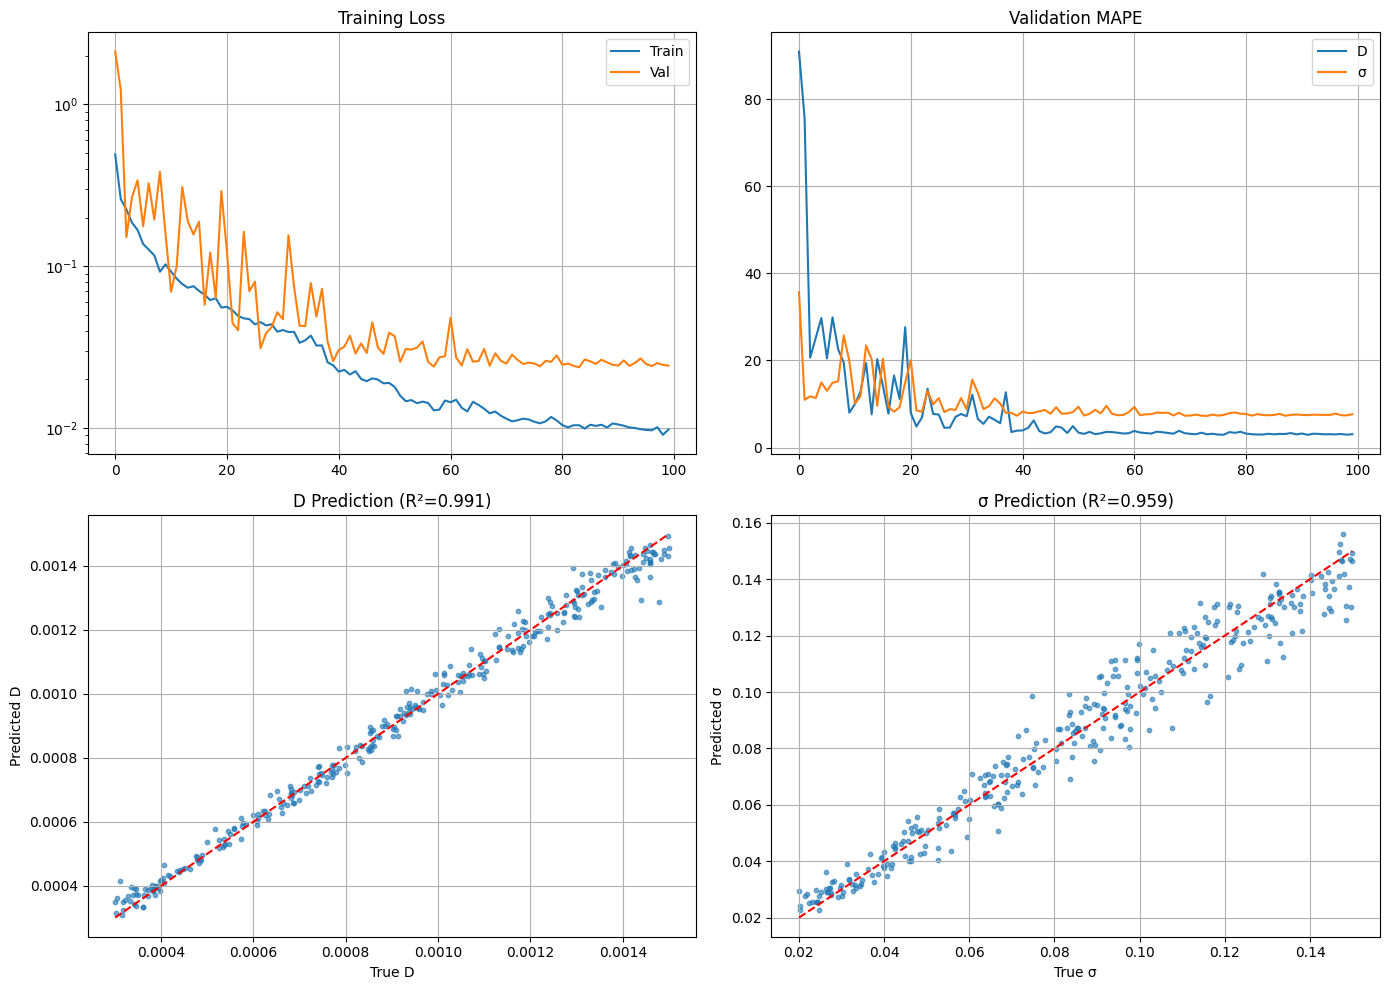

In [100]:
# ============================================================
# Training loop — STAGE 1
# Baseline + gradient + structure tensor
# PURE supervised (no FFT, no Corr, no surrogates)
# ============================================================


train_losses = []
val_losses = []

val_mae_D, val_rmse_D, val_mape_D = [], [], []
val_mae_sigma, val_rmse_sigma, val_mape_sigma = [], [], []

t_mean_t = torch.tensor(t_mean, device=device, dtype=torch.float32)
t_std_t  = torch.tensor(t_std,  device=device, dtype=torch.float32)

print(f"Starting STAGE 1 training for {EPOCHS} epochs...")
print("-" * 80)

for epoch in range(1, EPOCHS + 1):

    # ==========================
    #        TRAIN
    # ==========================
    model.train()
    running_train = 0.0
    n_batches = 0

    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = model(imgs)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        running_train += loss.item()
        n_batches += 1

    epoch_train_loss = running_train / n_batches
    train_losses.append(epoch_train_loss)

    # ==========================
    #      VALIDATION
    # ==========================
    model.eval()
    running_val = 0.0
    n_val_batches = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)

            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(imgs)
                loss = criterion(outputs, targets)

            running_val += loss.item()
            n_val_batches += 1

            preds_unnorm = outputs * t_std_t + t_mean_t
            targets_unnorm = targets * t_std_t + t_mean_t

            all_preds.append(preds_unnorm.cpu())
            all_targets.append(targets_unnorm.cpu())

    epoch_val_loss = running_val / n_val_batches
    val_losses.append(epoch_val_loss)

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    # --------------------------
    # Metrics (baseline-style)
    # --------------------------
    D_pred, D_true = all_preds[:, 0], all_targets[:, 0]
    s_pred, s_true = all_preds[:, 1], all_targets[:, 1]

    mae_D = torch.mean(torch.abs(D_pred - D_true)).item()
    rmse_D = torch.sqrt(torch.mean((D_pred - D_true)**2)).item()
    mape_D = torch.mean(torch.abs((D_pred - D_true)/(D_true + 1e-10))).item() * 100

    mae_s = torch.mean(torch.abs(s_pred - s_true)).item()
    rmse_s = torch.sqrt(torch.mean((s_pred - s_true)**2)).item()
    mape_s = torch.mean(torch.abs((s_pred - s_true)/(s_true + 1e-10))).item() * 100

    val_mae_D.append(mae_D)
    val_rmse_D.append(rmse_D)
    val_mape_D.append(mape_D)

    val_mae_sigma.append(mae_s)
    val_rmse_sigma.append(rmse_s)
    val_mape_sigma.append(mape_s)

    # ==========================
    # Scheduler & checkpoint
    # ==========================
    scheduler.step(epoch_val_loss)
    lr_now = optimizer.param_groups[0]["lr"]

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = model.state_dict().copy()

        torch.save({
            "model_state_dict": best_model_state,
            "target_mean": t_mean,
            "target_std": t_std,
            "epoch": epoch,
            "val_loss": epoch_val_loss
        }, BEST_PATH)

        saved_marker = " *"
    else:
        saved_marker = ""

    if epoch % 10 == 0 or epoch == 1 or saved_marker:
        print(
            f"Epoch {epoch:03d} | "
            f"Train {epoch_train_loss:.3e} | "
            f"Val {epoch_val_loss:.3e} | "
            f"D MAPE {mape_D:.1f}% | "
            f"σ MAPE {mape_s:.1f}% | "
            f"LR {lr_now:.1e}{saved_marker}"
        )

print("-" * 80)
print(f"Training complete! Best val loss: {best_val_loss:.4e}")

model.load_state_dict(best_model_state)
print("Best model restored.")

# ==========================
# Recompute predictions with BEST model
# ==========================
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)

        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = model(imgs)

        preds_unnorm = outputs * t_std_t + t_mean_t
        targets_unnorm = targets * t_std_t + t_mean_t

        all_preds.append(preds_unnorm.cpu())
        all_targets.append(targets_unnorm.cpu())

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

D_pred, D_true = all_preds[:, 0], all_targets[:, 0]
s_pred, s_true = all_preds[:, 1], all_targets[:, 1]


# ============================================================
# Final metrics & plots (baseline parity)
# ============================================================

def r2(y_pred, y_true):
    ss_res = torch.sum((y_true - y_pred)**2)
    ss_tot = torch.sum((y_true - torch.mean(y_true))**2)
    return (1 - ss_res / ss_tot).item()

r2_D = r2(D_pred, D_true)
r2_s = r2(s_pred, s_true)

print("\nFINAL VALIDATION METRICS")
print(f"D     → R²={r2_D:.3f}, MAE={mae_D:.4f}, RMSE={rmse_D:.4f}, MAPE={mape_D:.1f}%")
print(f"σ     → R²={r2_s:.3f}, MAE={mae_s:.4f}, RMSE={rmse_s:.4f}, MAPE={mape_s:.1f}%")

# --------------------------
# 4-panel plot (baseline-style)
# --------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(train_losses, label="Train")
axes[0,0].plot(val_losses, label="Val")
axes[0,0].set_yscale("log")
axes[0,0].set_title("Training Loss")
axes[0,0].legend()
axes[0,0].grid()

axes[0,1].plot(val_mape_D, label="D")
axes[0,1].plot(val_mape_sigma, label="σ")
axes[0,1].set_title("Validation MAPE")
axes[0,1].legend()
axes[0,1].grid()

axes[1,0].scatter(D_true, D_pred, s=10, alpha=0.6)
axes[1,0].plot([D_true.min(), D_true.max()],
               [D_true.min(), D_true.max()], "r--")
axes[1,0].set_title(f"D Prediction (R²={r2_D:.3f})")
axes[1,0].set_xlabel("True D")
axes[1,0].set_ylabel("Predicted D")
axes[1,0].grid()

axes[1,1].scatter(s_true, s_pred, s=10, alpha=0.6)
axes[1,1].plot([s_true.min(), s_true.max()],
               [s_true.min(), s_true.max()], "r--")
axes[1,1].set_title(f"σ Prediction (R²={r2_s:.3f})")
axes[1,1].set_xlabel("True σ")
axes[1,1].set_ylabel("Predicted σ")
axes[1,1].grid()

plt.tight_layout()
plt.savefig(FIG_DIR / f"stage1_results_{RUN_TAG}.png", dpi=300)
plt.show()


In [22]:
def get_ground_truth(img_path, df):
    """
    Extract run_id from filename mz_binary_<run_id>.png
    and look up (D, sigma) in a preloaded DataFrame.
    """
    filename = Path(img_path).stem  # mz_binary_123
    try:
        run_id = int(filename.split("_")[-1])
    except ValueError:
        raise ValueError(f"Cannot parse run_id from filename: {filename}")

    row = df[df[IMG_INDEX_COL] == run_id]

    if row.empty:
        raise KeyError(f"run_id {run_id} not found in CSV")

    return float(row.iloc[0][COL_D]), float(row.iloc[0][COL_SIGMA])


def load_model(path, device):
    """
    Load trained PhysicsNormalCNN model for inference.
    Returns model + target normalization.
    """
    checkpoint = torch.load(path, map_location=device, weights_only=False)

    model = PhysicsNormalCNN().to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    target_mean = torch.tensor(
        checkpoint["target_mean"],
        device=device,
        dtype=torch.float32
    )
    target_std = torch.tensor(
        checkpoint["target_std"],
        device=device,
        dtype=torch.float32
    )

    return model, target_mean, target_std



# -------------------------------------------------
# Transform for prediction (NO augmentations)
# -------------------------------------------------
predict_tf = T.Compose([
    T.ToTensor(),
])


In [23]:
# -----------------------------
# 8) Execution: Predict & Compare
# -----------------------------

# -------------------------------------------------
# Prediction function (clean, physical units)
# -------------------------------------------------
def predict_image(img_path, model, target_mean, target_std, device):
    img = Image.open(img_path).convert("L")
    img = predict_tf(img)

    if img.shape[0] == 1:
        img = img.repeat(3, 1, 1)

    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        out_norm = model(img).squeeze(0)   # normalized (D, sigma)
        out_phys = out_norm * target_std + target_mean

    return float(out_phys[0].item()), float(out_phys[1].item())


# -------------------------------------------------
# Load trained PhysicsNormal model (FFT_corr)
# -------------------------------------------------
model, tm, ts = load_model(BEST_PATH, device)

# Preload CSV once (efficient + clean)
gt_df = pd.read_csv(CSV_PATH)

# Example image
test_img_path = "../dataset_combined/images/mz_binary_1033.png"

# Predict
pred_D, pred_sigma = predict_image(
    test_img_path, model, tm, ts, device
)

# Ground truth
real_D, real_sigma = get_ground_truth(test_img_path, gt_df)

# -------------------------------------------------
# Report
# -------------------------------------------------
print("-" * 60)
print(f"Model: PhysicsNormalCNN ({RUN_TAG})")
print(f"Image: {Path(test_img_path).name}")
print("-" * 60)
print(f"{'Parameter':<10} | {'Real':<12} | {'Predicted':<12} | {'Abs Error':<12}")
print("-" * 60)
print(f"{'D':<10} | {real_D:.6f} | {pred_D:.6f} | {abs(pred_D-real_D):.6f}")
print(f"{'Sigma':<10} | {real_sigma:.6f} | {pred_sigma:.6f} | {abs(pred_sigma-real_sigma):.6f}")
print("-" * 60)


------------------------------------------------------------
Model: PhysicsNormalCNN (FFT_corr_)
Image: mz_binary_1033.png
------------------------------------------------------------
Parameter  | Real         | Predicted    | Abs Error   
------------------------------------------------------------
D          | 0.000790 | 0.001115 | 0.000325
Sigma      | 0.122045 | 0.154087 | 0.032042
------------------------------------------------------------


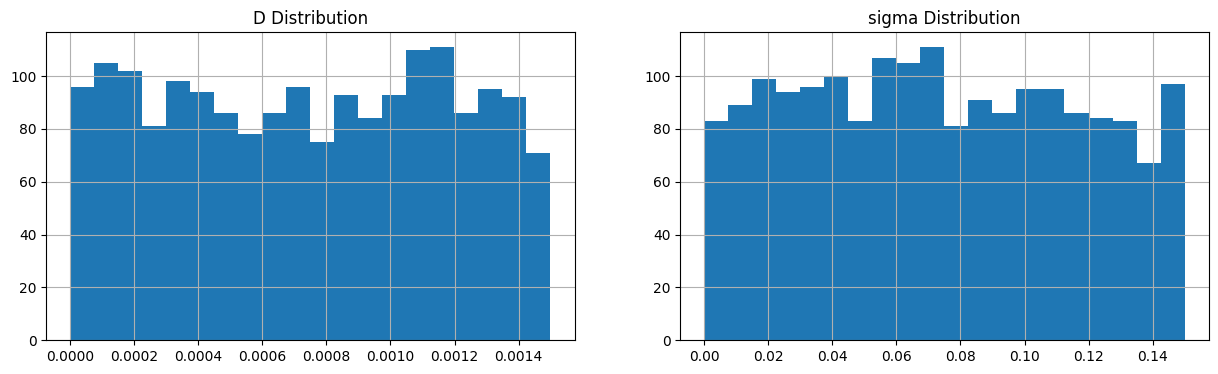

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../dataset_combined/training_index.csv")

plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
df["Dind"].hist(bins=20)
plt.title("D Distribution")

plt.subplot(1,2,2)
df["sigma"].hist(bins=20)
plt.title("sigma Distribution")

plt.show()


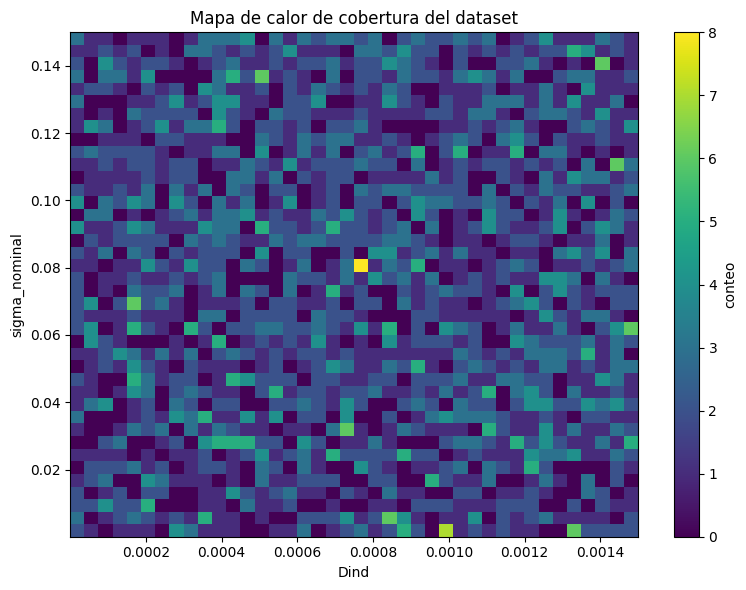

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_D_sigma_heatmap(
    csv_path,
    D_col="Dind",
    sigma_col="sigma",
    bins_D=30,
    bins_sigma=30,
    log_scale=True
):
    """
    Genera un mapa de calor del conteo de muestras en el plano (D, sigma)

    Parameters
    ----------
    csv_path : str
        Ruta al archivo CSV
    D_col : str
        Nombre de la columna de D
    sigma_col : str
        Nombre de la columna de sigma
    bins_D : int
        Número de bins para D
    bins_sigma : int
        Número de bins para sigma
    log_scale : bool
        Si True, usa escala logarítmica para el color
    """

    # ---------------------------
    # Leer datos
    # ---------------------------
    #
    df = pd.read_csv(csv_path)
    #df = pd.read_csv("../mumax_dataset_ku_by_block_disorder_phy_corrected_2/training_index.csv")

    if D_col not in df.columns or sigma_col not in df.columns:
        raise ValueError("Las columnas especificadas no existen en el CSV")

    D = df[D_col].values
    sigma = df[sigma_col].values


    # ---------------------------
    # Binning y conteo
    # ---------------------------
    H, D_edges, sigma_edges = np.histogram2d(
        D,
        sigma,
        bins=[bins_D, bins_sigma]
    )

    if log_scale:
        H = np.log10(H + 1.0)

    # ---------------------------
    # Plot
    # ---------------------------
    plt.figure(figsize=(8, 6))

    extent = [
        D_edges[0], D_edges[-1],
        sigma_edges[0], sigma_edges[-1]
    ]

    im = plt.imshow(
        H.T,
        origin="lower",
        aspect="auto",
        extent=extent
    )

    cbar = plt.colorbar(im)
    cbar.set_label("log10(conteo + 1)" if log_scale else "conteo")

    plt.xlabel(D_col)
    plt.ylabel(sigma_col)
    plt.title("Mapa de calor de cobertura del dataset")

    plt.tight_layout()
    #plt.savefig("D_sigma_heatmap_combined_1000.png", dpi=300)
    plt.savefig(FIG_DIR / "D_sigma_heatmap_combined_1632.png", dpi=300)
    plt.show()


plot_D_sigma_heatmap(
    csv_path="../mumax_dataset_ku_by_block_disorder_phy_corrected_3/training_index.csv",
    D_col="Dind",
    sigma_col="sigma_nominal",
    bins_D=40,
    bins_sigma=40,
    log_scale=False
)


In [ ]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm


def collect_prediction_errors(
    image_dir,
    df_gt,
    model,
    target_mean,
    target_std,
    device,
):
    """
    Run inference on all images listed in df_gt and
    collect prediction errors for D and sigma.

    Parameters
    ----------
    image_dir : str or Path
        Directory containing mz_binary_<run_id>.png images
    df_gt : pd.DataFrame
        Ground-truth DataFrame (loaded once)
    model : torch.nn.Module
        Trained PhysicsNormalCNN
    target_mean, target_std : torch.Tensor
        Normalization tensors (on device)
    device : torch.device
    """

    records = []
    image_dir = Path(image_dir)

    for row in tqdm(df_gt.itertuples(index=False), total=len(df_gt), desc="Predicting"):
        run_id = int(getattr(row, IMG_INDEX_COL))
        img_path = image_dir / f"{IMG_PREFIX}{run_id}{IMG_EXT}"

        if not img_path.exists():
            raise FileNotFoundError(
                f"Missing image for run_id={run_id}: {img_path}"
            )

        # --------------------------
        # Ground truth
        # --------------------------
        real_D = float(getattr(row, COL_D))
        real_sigma = float(getattr(row, COL_SIGMA))

        # --------------------------
        # Prediction
        # --------------------------
        pred_D, pred_sigma = predict_image(
            img_path,
            model,
            target_mean,
            target_std,
            device
        )

        records.append({
            "run_id": run_id,
            "Dind": real_D,
            "sigma": real_sigma,
            "pred_D": pred_D,
            "pred_sigma": pred_sigma,
            "err_D": abs(pred_D - real_D),
            "err_sigma": abs(pred_sigma - real_sigma),
        })

    return pd.DataFrame.from_records(records)


# -------------------------------------------------
# Run evaluation
# -------------------------------------------------

# Load GT once
df_gt = pd.read_csv(CSV_PATH)

model, tm, ts = load_model(BEST_PATH, device)

df_err = collect_prediction_errors(
    image_dir=IMG_DIR,
    df_gt=df_gt,
    model=model,
    target_mean=tm,
    target_std=ts,
    device=device,
)

print(df_err.head(20))


Predicting: 100%|██████████| 2689/2689 [00:23<00:00, 112.20it/s]

    run_id      Dind     sigma    pred_D  pred_sigma     err_D  err_sigma
0        1  0.000679  0.067192  0.001413    0.287393  0.000734   0.220201
1        2  0.000630  0.019834  0.001231    0.205271  0.000602   0.185437
2        3  0.001337  0.024939  0.001417    0.244867  0.000080   0.219928
3        4  0.001446  0.029623  0.001281    0.235604  0.000165   0.205981
4        5  0.001437  0.000577  0.000707    0.173879  0.000730   0.173301
5        6  0.001122  0.054259  0.001428    0.273214  0.000306   0.218955
6        7  0.000325  0.114787  0.001258    0.249230  0.000933   0.134443
7        8  0.000313  0.041479  0.001372    0.282736  0.001059   0.241257
8        9  0.000872  0.030044  0.001313    0.243574  0.000440   0.213529
9       10  0.000211  0.101816  0.001308    0.259669  0.001097   0.157852
10      11  0.000682  0.000070  0.001186    0.203078  0.000504   0.203008
11      12  0.001120  0.080233  0.001627    0.324153  0.000506   0.243921
12      13  0.001066  0.024280  0.0012

(0.0, 0.0014)

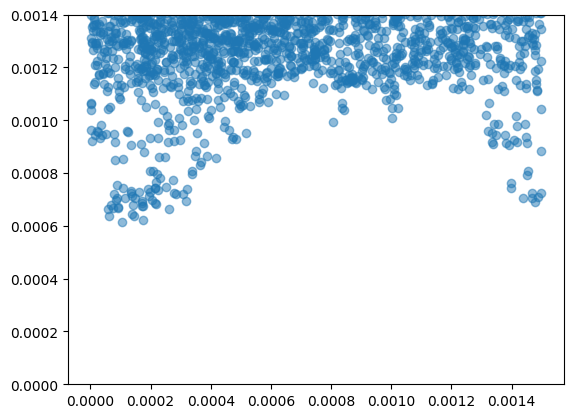

In [31]:
plt.plot(df_err["Dind"], df_err["pred_D"], 'o', alpha=0.5)
plt.ylim(0,0.0014)

(0.0, 0.14)

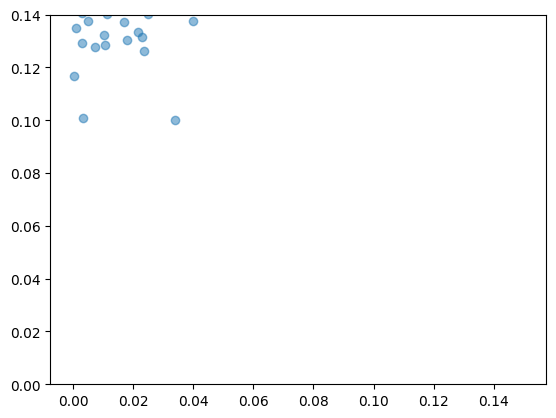

In [32]:
plt.plot(df_err["sigma"], df_err["pred_sigma"], 'o', alpha=0.5)
plt.ylim(0,0.14)

In [26]:
df_err.head()

,run_id,Dind,sigma,pred_D,pred_sigma,err_D,err_sigma
0,1,0.000679,0.067192,0.001413,0.287393,0.000734,0.220201
1,2,0.000630,0.019834,0.001231,0.205271,0.000602,0.185437
2,3,0.001337,0.024939,0.001417,0.244867,0.000080,0.219928
3,4,0.001446,0.029623,0.001281,0.235604,0.000165,0.205981
4,5,0.001437,0.000577,0.000707,0.173879,0.000730,0.173301


In [27]:
import numpy as np
import matplotlib.pyplot as plt


def plot_error_heatmap(
    df_err,
    df_limits,
    D_col="Dind",
    sigma_col="sigma",
    err_col="err_D",
    bins_D=40,
    bins_sigma=40,
    statistic="mean",          # "mean" or "median"
    title="",
    cmap="inferno",
    vmin=None,
    vmax=None,
    save_path=None,
    absolute=False,            # |error porcentual|
    clip_percentile=None       # e.g. 95 or 99
):
    """
    Heatmap of percentage prediction error in the (D, sigma) plane.

    Error definition (per prediction):
        e = 100 * (pred - true) / true

    Optional:
        clip_percentile = p
        → removes errors with |e| > percentile_p(|e|)
    """

    # --------------------------------------------------
    # 1. Physical domain
    # --------------------------------------------------
    df_limits = df_limits.dropna(subset=[D_col, "sigma_nominal"])

    D_min, D_max = df_limits[D_col].min(), df_limits[D_col].max()
    s_min, s_max = df_limits["sigma_nominal"].min(), df_limits["sigma_nominal"].max()

    if D_min == D_max or s_min == s_max:
        raise ValueError("Degenerate range in D or sigma")

    # --------------------------------------------------
    # 2. Physical bins
    # --------------------------------------------------
    D_edges = np.linspace(D_min, D_max, bins_D + 1)
    s_edges = np.linspace(s_min, s_max, bins_sigma + 1)

    # --------------------------------------------------
    # 3. Clean data
    # --------------------------------------------------
    df = df_err.dropna(subset=[D_col, sigma_col, err_col])

    D = df[D_col].values
    s = df[sigma_col].values
    err_abs = df[err_col].values  # pred - true

    # --------------------------------------------------
    # 4. Percentage error per prediction
    # --------------------------------------------------
    if "sigma" in err_col.lower():
        true_val = s
    else:
        true_val = D

    with np.errstate(divide="ignore", invalid="ignore"):
        e = 100.0 * err_abs / true_val

    if absolute:
        e = np.abs(e)

    # Remove non-finite values first
    finite = np.isfinite(e)
    D, s, e = D[finite], s[finite], e[finite]

    # --------------------------------------------------
    # 5. Clip extreme percentage errors (global)
    # --------------------------------------------------
    if clip_percentile is not None:
        if not (0 < clip_percentile < 100):
            raise ValueError("clip_percentile must be between 0 and 100")

        thr = np.percentile(np.abs(e), clip_percentile)
        keep = np.abs(e) <= thr

        D, s, e = D[keep], s[keep], e[keep]

    # --------------------------------------------------
    # 6. Bin assignment
    # --------------------------------------------------
    iD = np.searchsorted(D_edges, D, side="right") - 1
    iS = np.searchsorted(s_edges, s, side="right") - 1

    valid = (
        (iD >= 0) & (iD < bins_D) &
        (iS >= 0) & (iS < bins_sigma)
    )

    iD, iS, e = iD[valid], iS[valid], e[valid]

    # --------------------------------------------------
    # 7. Accumulate statistics
    # --------------------------------------------------
    heatmap = np.full((bins_D, bins_sigma), np.nan)
    counts  = np.zeros((bins_D, bins_sigma), dtype=int)

    if statistic == "mean":
        sum_err = np.zeros((bins_D, bins_sigma), dtype=float)
        np.add.at(sum_err, (iD, iS), e)
        np.add.at(counts,  (iD, iS), 1)

        with np.errstate(divide="ignore", invalid="ignore"):
            heatmap = sum_err / counts
            heatmap[counts == 0] = np.nan

    elif statistic == "median":
        bins = [[[] for _ in range(bins_sigma)] for _ in range(bins_D)]
        for d, s_, err in zip(iD, iS, e):
            bins[d][s_].append(err)

        for i in range(bins_D):
            for j in range(bins_sigma):
                if bins[i][j]:
                    heatmap[i, j] = np.median(bins[i][j])
                    counts[i, j] = len(bins[i][j])

    else:
        raise ValueError("statistic must be 'mean' or 'median'")

    # --------------------------------------------------
    # 8. Plot
    # --------------------------------------------------
    plt.figure(figsize=(8, 6))
    im = plt.imshow(
        heatmap.T,
        origin="lower",
        aspect="auto",
        extent=[D_min, D_max, s_min, s_max],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    cbar = plt.colorbar(im)

    label = "Percentage error [%]"
    if absolute:
        label = "Absolute percentage error [%]"
    if clip_percentile is not None:
        label += f" (clipped at {clip_percentile}th pct)"

    cbar.set_label(label)

    plt.xlabel(D_col)
    plt.ylabel(sigma_col)
    plt.title(title)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()

    return heatmap, counts


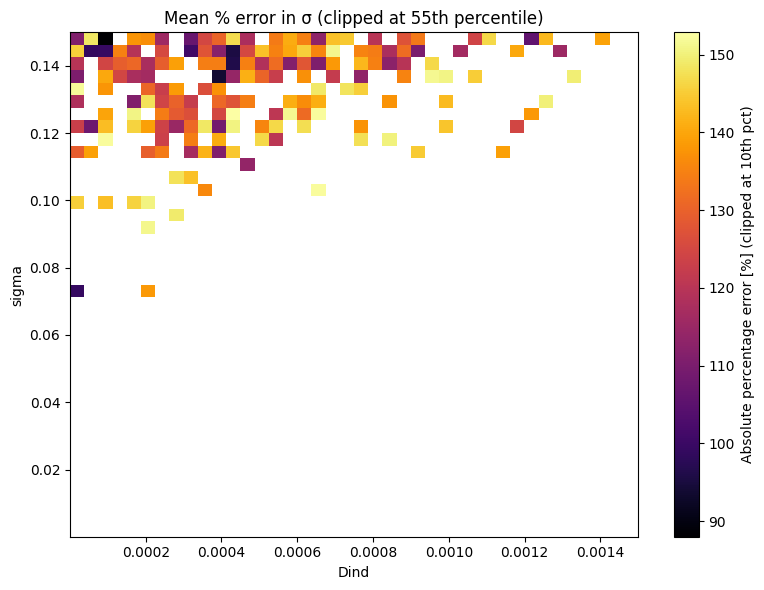

(array([[         nan,          nan,          nan, ..., 119.88524066,
         145.45425477, 110.9466163 ],
        [         nan,          nan,          nan, ...,          nan,
          98.91018697, 148.78010765],
        [         nan,          nan,          nan, ..., 124.45818191,
          99.42830901,  87.98158717],
        ...,
        [         nan,          nan,          nan, ...,          nan,
                  nan, 139.55289372],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan]], shape=(40, 40)),
 array([[0, 0, 0, ..., 2, 1, 3],
        [0, 0, 0, ..., 0, 1, 1],
        [0, 0, 0, ..., 4, 2, 1],
        ...,
        [0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(40, 40)))

In [28]:
df_limits = pd.read_csv(CSV_PATH)

# Error en sigma 
plot_error_heatmap(
    df_err=df_err,
    df_limits=df_limits,
    err_col="err_sigma",
    statistic="mean",
    absolute=True,
    clip_percentile=10,
    title="Mean % error in σ (clipped at 55th percentile)"
)


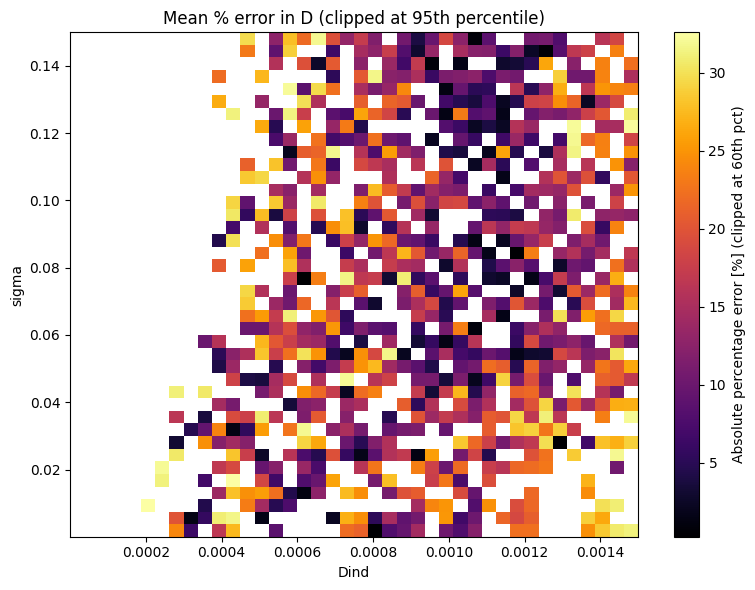

(array([[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [28.54307008, 26.31768913, 29.94638216, ..., 23.71665879,
                 nan, 16.24041161],
        [30.71174755,         nan, 31.03833589, ...,         nan,
         23.73710854, 18.55632307],
        [31.31306426,         nan,         nan, ..., 22.34118363,
                 nan,         nan]], shape=(40, 40)),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [2, 1, 1, ..., 6, 0, 3],
        [2, 0, 1, ..., 0, 2, 1],
        [1, 0, 0, ..., 1, 0, 0]], shape=(40, 40)))

In [21]:

plot_error_heatmap(
    df_err=df_err,
    df_limits=df_limits,
    err_col="err_D",
    statistic="mean",
    absolute=True,
    clip_percentile=60,
    title="Mean % error in D (clipped at 95th percentile)"
)


In [22]:
def collect_surrogate_errors(
    surr_dataset,
    surrogate,
    Phi_mean,
    Phi_std,
    compute_phi_bar_fn,
    device,
):
    """
    Evaluate surrogate error per (D, sigma).

    compute_phi_bar_fn:
        function(img_paths, device) -> Phi_bar (REAL)
    """

    records = []

    surrogate.eval()

    with torch.no_grad():
        for item in surr_dataset:
            params = item["params"].to(device)  # [2]
            img_paths = item["img_paths"]

            # True Phi_bar from images
            Phi_bar_real = compute_phi_bar_fn(img_paths, device)
            Phi_bar_real = (Phi_bar_real - Phi_mean) / Phi_std

            # Surrogate prediction
            Phi_bar_pred = surrogate(params.unsqueeze(0)).squeeze(0)

            # Error (L2 norm in Phi-space)
            err_phi = torch.norm(Phi_bar_pred - Phi_bar_real).item()

            records.append({
                "Dind": float(params[0].item()),
                "sigma": float(params[1].item()),
                "err_phi": err_phi
            })

    return pd.DataFrame(records)


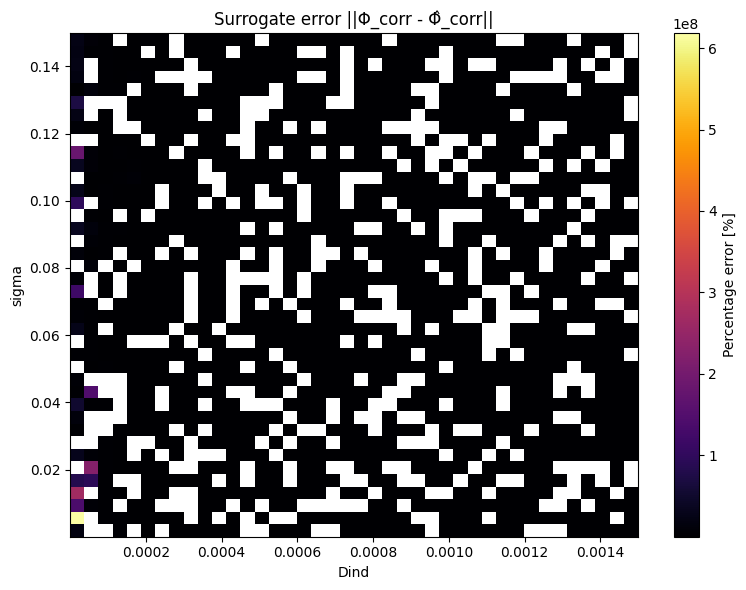

(array([[1.80065566e+07, 6.18790210e+08, 1.38970879e+08, ...,
         2.34642110e+07, 2.09843169e+07, 2.35181775e+07],
        [           nan,            nan, 5.58655627e+06, ...,
                    nan, 3.20103935e+06, 9.39174852e+06],
        [           nan, 3.65026745e+06, 4.01880612e+06, ...,
         2.63483601e+06, 4.74184687e+06, 4.73166581e+06],
        ...,
        [1.39388209e+05, 1.43618339e+05, 4.40352694e+05, ...,
         2.03861276e+05,            nan, 2.36029382e+05],
        [1.62157826e+05,            nan, 2.18967740e+05, ...,
                    nan, 2.95533143e+05, 1.98940086e+05],
        [1.59365983e+05, 1.57238513e+05, 1.91858976e+05, ...,
         2.22718300e+04,            nan,            nan]], shape=(40, 40)),
 array([[2, 3, 2, ..., 2, 1, 3],
        [0, 0, 2, ..., 0, 1, 1],
        [0, 1, 4, ..., 4, 2, 1],
        ...,
        [1, 1, 2, ..., 6, 0, 2],
        [2, 0, 1, ..., 0, 2, 2],
        [2, 2, 1, ..., 1, 0, 0]], shape=(40, 40)))

In [23]:
df_surr_err_corr = collect_surrogate_errors(
    surr_dataset=train_surr,   # o val_surr
    surrogate=surrogate_corr,
    Phi_mean=Phi_corr_mean,
    Phi_std=Phi_corr_std,
    compute_phi_bar_fn=compute_phi_bar_corr,
    device=device
)

plot_error_heatmap(
    df_err=df_surr_err_corr,
    df_limits=df_limits,
    err_col="err_phi",
    title="Surrogate error ||Φ_corr - Φ̂_corr||",
    save_path=FIG_DIR / "heatmap_surrogate_corr_error.png"
)


[Domain] D:     1.06272e-07 → 0.00149959
[Domain] sigma: 6.77804e-05 → 0.149908


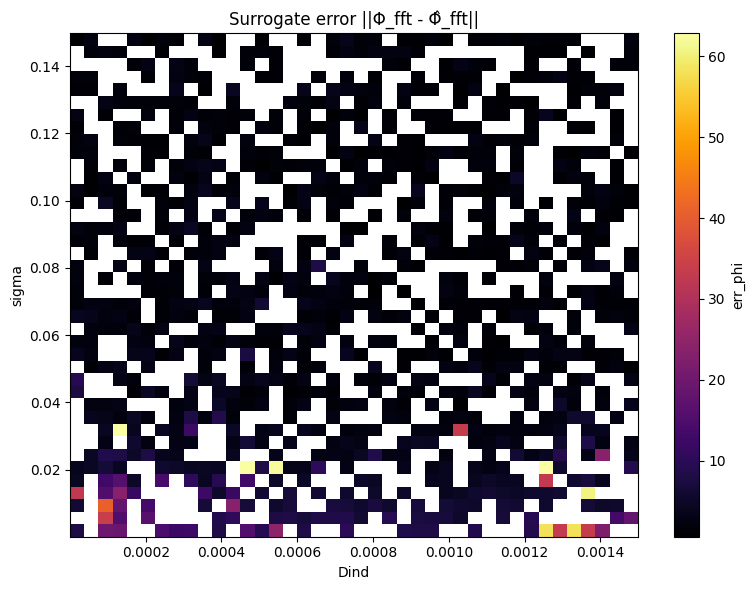

(array([[ 8.10305405,         nan,  6.28493214, ...,         nan,
                 nan,  0.6891219 ],
        [        nan,         nan,         nan, ...,         nan,
          1.60816163,  2.38881663],
        [19.68602562, 33.76094341, 40.79875278, ...,         nan,
          2.08498597,         nan],
        ...,
        [22.14235306,         nan,  5.46644115, ...,         nan,
                 nan,         nan],
        [        nan, 13.43011189,  5.50179148, ...,  1.80041337,
                 nan,         nan],
        [        nan, 18.06226349,         nan, ...,  1.58394808,
          1.68549848,  2.23123622]], shape=(40, 40)),
 array([[1, 0, 2, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 2, 3],
        [1, 2, 2, ..., 0, 1, 0],
        ...,
        [1, 0, 1, ..., 0, 0, 0],
        [0, 2, 2, ..., 1, 0, 0],
        [0, 1, 0, ..., 2, 1, 1]], shape=(40, 40)))

In [35]:
df_surr_err_fft = collect_surrogate_errors(
    surr_dataset=train_surr,          # o val_surr (mejor usar val)
    surrogate=surrogate_fft,
    Phi_mean=Phi_fft_mean,
    Phi_std=Phi_fft_std,
    compute_phi_bar_fn=compute_phi_bar_fft,
    device=device
)

plot_error_heatmap(
    df_err=df_surr_err_fft,
    df_limits=df_limits,
    err_col="err_phi",
    title="Surrogate error ||Φ_fft - Φ̂_fft||",
    save_path=FIG_DIR / "heatmap_surrogate_fft_error.png"
)



In [34]:
def summarize_err(df, col="err_phi"):
    x = df[col].dropna().values
    print("N:", len(x))
    print("min/median/mean/max:", x.min(), np.median(x), x.mean(), x.max())
    for q in [0.9, 0.95, 0.99]:
        print(f"p{int(q*100)}:", np.quantile(x, q))

summarize_err(df_surr_err_corr, "err_phi")
summarize_err(df_surr_err_fft,  "err_phi")


N: 933
min/median/mean/max: 0.05494440719485283 2.069944381713867 2.982969098132491 58.231101989746094
p90: 4.631084728240971
p95: 5.910117721557617
p99: 31.513448486326716
N: 933
min/median/mean/max: 0.4493953287601471 1.9875651597976685 3.436617344234534 67.81924438476562
p90: 5.508605003356938
p95: 7.746225357055664
p99: 23.029521789550753


[Domain] D:     1.06272e-07 → 0.00149959
[Domain] sigma: 6.77804e-05 → 0.149908


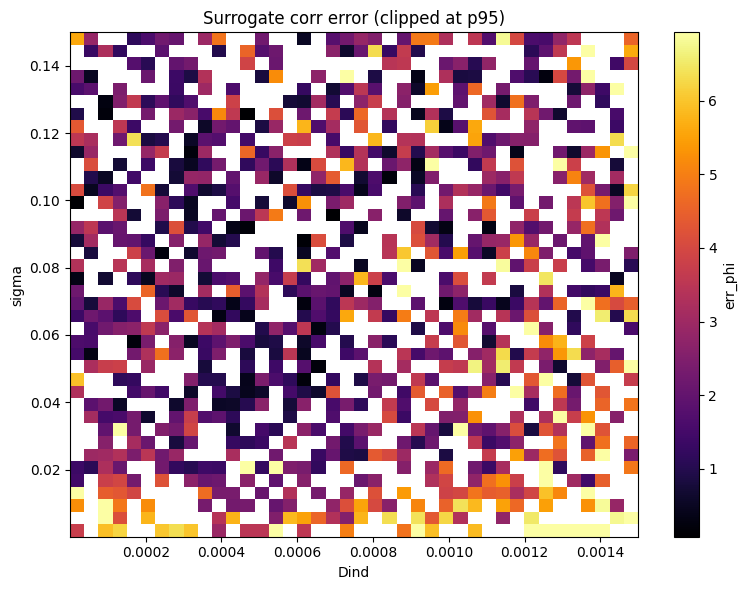

[Domain] D:     1.06272e-07 → 0.00149959
[Domain] sigma: 6.77804e-05 → 0.149908


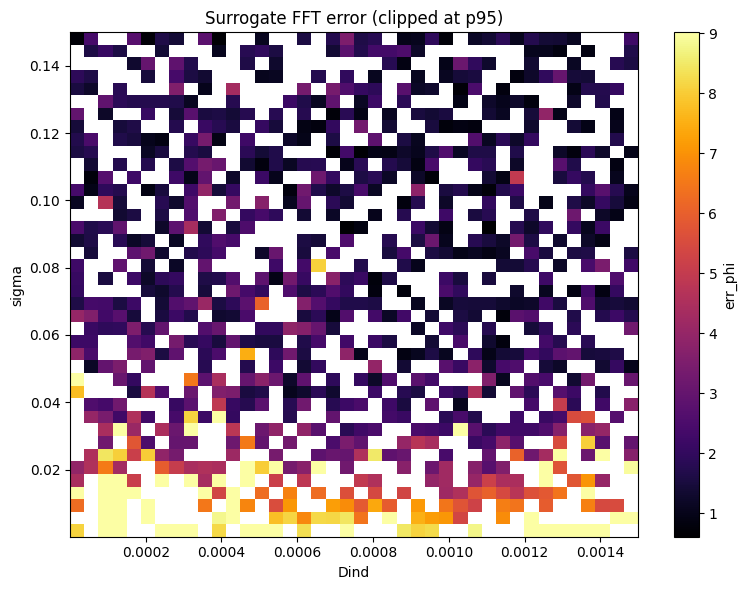

(array([[ 8.10305405,         nan,  6.28493214, ...,         nan,
                 nan,  0.6891219 ],
        [        nan,         nan,         nan, ...,         nan,
          1.60816163,  2.38881663],
        [19.68602562, 33.76094341, 40.79875278, ...,         nan,
          2.08498597,         nan],
        ...,
        [22.14235306,         nan,  5.46644115, ...,         nan,
                 nan,         nan],
        [        nan, 13.43011189,  5.50179148, ...,  1.80041337,
                 nan,         nan],
        [        nan, 18.06226349,         nan, ...,  1.58394808,
          1.68549848,  2.23123622]], shape=(40, 40)),
 array([[1, 0, 2, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 2, 3],
        [1, 2, 2, ..., 0, 1, 0],
        ...,
        [1, 0, 1, ..., 0, 0, 0],
        [0, 2, 2, ..., 1, 0, 0],
        [0, 1, 0, ..., 2, 1, 1]], shape=(40, 40)))

In [36]:
vmax_corr = np.quantile(df_surr_err_corr["err_phi"].dropna(), 0.95)
plot_error_heatmap(
    df_err=df_surr_err_corr,
    df_limits=df_limits,
    err_col="err_phi",
    title="Surrogate corr error (clipped at p95)",
    vmax=vmax_corr
)

vmax_fft = np.quantile(df_surr_err_fft["err_phi"].dropna(), 0.95)
plot_error_heatmap(
    df_err=df_surr_err_fft,
    df_limits=df_limits,
    err_col="err_phi",
    title="Surrogate FFT error (clipped at p95)",
    vmax=vmax_fft
)
